### 1. Dependencies

In [1]:
import wrds
import datetime
import numpy as np
import pandas as pd
from itertools import chain
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import univariate_portfolio_sorting, conditional_pct_change, standardize_pivot, low_high

# Set LaTeX rendering for legend entries
plt.rcParams['text.usetex'] = False

# Function to get the last non-NaN value in each group
def last_non_nan(series):
    return series.dropna().iloc[-1] if not series.dropna().empty else np.nan

def standardize_df_rows(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

In [2]:
# MANUAL INPUT
download_wrds_data = False#True
download_ff_data = False#True
esg_choice = 'none'          # 's&p' or 'refinitiv' or 'none'
res_suffix = f'{esg_choice}_esg_2013' # suffix for output tables and figures
start_year = 2013                 # these ESG sources are aligned for `start_year==2013`
end_year = 2024
#for accounting data
end_date = '2024-12-31'
no_simple_quantiles = 6


#Golden Dataset Location
golden_location = "C:/Users/chris/Documents/GitHub/data/Golden_Data"
# Golden Dataset
#lc = pd.read_parquet(f'{golden_location}/LC_dataset_v_1_1O_master.parquet')
lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2A.csv')


# Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

# Filters

In [3]:
Filter_RealEstate_and_Financials = False

### 2. Data

#### 2.1 LC dataset

In [4]:
lc.dropna(subset=['gvkey'], inplace=True)

# Change types to align with WRDS
lc['gvkey'] = lc['gvkey'].astype(int).astype(str)
lc['rfyear'] = lc['rfyear'].astype('Int64')

# Keep rows with some minimum information
lc = lc.dropna(subset=['gvkey', 'rfyear', 'loc', 'MacroRegion', 'GICS_level_1', 'GICS_level_2', 'GICS_level_3'])

# Filter rows where MacroRegion is in the specified list
regions = ["Asia-Pacific", "Europe", "United States and Canada"]
lc = lc[lc['MacroRegion'].isin(regions)]

# Filter data to keep observatios from `start_year`
lc = lc[lc['rfyear'] >= start_year]
lc = lc[lc['rfyear'] <= end_year]

def map_sectors(x):
    # Skip Industrials, Health Care, Utilities
    if x in ['Energy', 'Materials']:
        return 'Primary Industries'
    elif x in ['Consumer Discretionary', 'Consumer Staples']:
        return 'Consumer'

    # make Financial = Financials if you want to include finance sector
    elif x in ['Financials', 'Real Estate']:
        return 'Financial'
    elif x in ['Communication Services', 'Information Technology']:
        return 'ICT'
    return x




print(lc['GICS_level_1'].unique())
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
print(lc['Industry'].unique())



# Filter data to drop Energy
# lc = lc[~lc['Industry'].isin(['Energy'])]


# # Merge `Real Estate` and `Financial`
# lc.loc[lc['GICS_level_1'] == 'Real Estate', 'GICS_level_1'] = 'Financial'

# # Filter data to drop Financial and RE
# if Filter_RealEstate_and_Financials == True:
#     lc = lc[~lc['GICS_level_1'].isin(['Financial', 'Real Estate'])]
#     print("Filtered out Financial and Real Estate")

# # Filter to keep a stable panel
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]



#FILTER OUT FINANCIALS

if Filter_RealEstate_and_Financials == True:
    lc = lc[lc["Industry"] != "Financial"]

['Industrials' 'Health Care' 'Materials' 'Utilities' 'Energy'
 'Consumer Discretionary' 'Real Estate' 'Information Technology'
 'Communication Services' 'Financials' 'Consumer Staples']
['Industrials' 'Health Care' 'Primary Industries' 'Utilities' 'Consumer'
 'Financial' 'ICT']


In [5]:
lc["Industry"].unique()

array(['Industrials', 'Health Care', 'Primary Industries', 'Utilities',
       'Consumer', 'Financial', 'ICT'], dtype=object)

In [6]:
'''
Dictionary specifying types categories

Stakeholders:
  - customers
  - employees
  - enviroment
  - local communities and society
  - nothing
  - shareholders
  - suppliers
'''

# Actions
categories_dict_actions = {
  'advocacy, preparation, transformation':
    {
      # 'TYPE: association': 0, 
      # 'TYPE: pricing': 2,                                                             # For our universe, these are usually discounts to disadvantaged customers
      'TYPE: donation & funding': 0, 
      'TYPE: volunteerism': 0, 
      'TYPE_SREC: communication - local communities and society': 0, 
      'TYPE_SREC: training - local communities and society': 0,                       # For our universe, these are usually akin to volunteering activities
      'TYPE_SREC: incentives - local communities and society': 0,                     # For our universe, these are usually `donation & funding` through vouchers etc.
      'TYPE_SREC: organizational structuring - local communities and society': 0, 

      'TYPE: adoption of standards and rules': 1, 
      'TYPE: assessment and measurement': 1,                                          # For our universe, these are mostly partnerships (e.g., with ONGs) for enviromental/social impact assessments
      'TYPE_SREC: communication - employees': 1, 
      'TYPE_SREC: training - employees': 1, 
      'TYPE_SREC: incentives - employees': 1, 
      'TYPE_SREC: organizational structuring - employees': 1, 

      'TYPE: asset modification': 2,
      'TYPE: modification of procedures': 2, 
      'TYPE: new products': 2, 
      'TYPE: r&d investments': 2, 
      'TYPE_SREC: communication - customers': 2, 
      'TYPE_SREC: communication - shareholders': 2, 
      'TYPE_SREC: communication - suppliers': 2, 
      'TYPE_SREC: training - customers': 2, 
      'TYPE_SREC: training - shareholders': 2, 
      'TYPE_SREC: training - suppliers': 2, 
      'TYPE_SREC: incentives - customers': 2, 
      'TYPE_SREC: incentives - shareholders': 2, 
      'TYPE_SREC: incentives - suppliers': 2, 
      'TYPE_SREC: organizational structuring - customers': 2, 
      'TYPE_SREC: organizational structuring - shareholders': 2, 
      'TYPE_SREC: organizational structuring - suppliers': 2, 
  },
}

# MANUAL INPUT
# Choose which action characterization to use
categories_dict_actions = categories_dict_actions['advocacy, preparation, transformation']

In [7]:
"""
# People vs Planet SDGs
categories_dict_sdgs = {
  'SDG: 1': 0,
  'SDG: 2': 0,
  'SDG: 3': 0,
  'SDG: 4': 0,
  'SDG: 5': 0,
  'SDG: 8': 0,
  'SDG: 10': 0,
  'SDG: 6': 1,
  'SDG: 7': 1,
  'SDG: 12': 1,
  'SDG: 13': 1,
  'SDG: 14': 1,
  'SDG: 15': 1
}

# Initialise dictionary
categories_dict_people = {}
categories_dict_planet = {}

# Initialise other dictionaries
categories_dict_people_advocacy = {}
categories_dict_planet_advocacy = {}

# Loop over actions
for key_action, value_action in categories_dict_actions.items():

    # Loop over sdgs
    for key_sdg, value_sdg in categories_dict_sdgs.items():
        
        # Planet-related activities
        if value_sdg == 1:
            categories_dict_planet[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = value_action
            categories_dict_planet_advocacy[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = 2-value_action
            
        else:
            categories_dict_people[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = value_action
            categories_dict_people_advocacy[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = 2-value_action
"""

'\n# People vs Planet SDGs\ncategories_dict_sdgs = {\n  \'SDG: 1\': 0,\n  \'SDG: 2\': 0,\n  \'SDG: 3\': 0,\n  \'SDG: 4\': 0,\n  \'SDG: 5\': 0,\n  \'SDG: 8\': 0,\n  \'SDG: 10\': 0,\n  \'SDG: 6\': 1,\n  \'SDG: 7\': 1,\n  \'SDG: 12\': 1,\n  \'SDG: 13\': 1,\n  \'SDG: 14\': 1,\n  \'SDG: 15\': 1\n}\n\n# Initialise dictionary\ncategories_dict_people = {}\ncategories_dict_planet = {}\n\n# Initialise other dictionaries\ncategories_dict_people_advocacy = {}\ncategories_dict_planet_advocacy = {}\n\n# Loop over actions\nfor key_action, value_action in categories_dict_actions.items():\n\n    # Loop over sdgs\n    for key_sdg, value_sdg in categories_dict_sdgs.items():\n\n        # Planet-related activities\n        if value_sdg == 1:\n            categories_dict_planet[f\'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}\'] = value_action\n            categories_dict_planet_advocacy[f\'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}\'] = 2-value_action\

In [8]:
# MANUAL INPUT

#change below to the above sdg - evn and non env>
categories_dict = categories_dict_actions
plt_title_suffix = 'Innovation'
plt_max_to_min_title_suffix = 'Innovation to advocacy'

# FIND MIN AND MAX CATEGORY ID
min_category = min(categories_dict.values())
max_category = max(categories_dict.values())

In [9]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

In [10]:
lc["sum_activities"].describe()

count    59673.000000
mean        28.327166
std         31.978546
min          0.000000
25%          9.000000
50%         19.000000
75%         36.000000
max        699.000000
Name: sum_activities, dtype: float64

In [11]:
# Exclude entries with too few/many activities
lower_bound = lc.groupby('rfyear')['sum_activities'].transform(lambda x: x.quantile(alpha_bound/2))
upper_bound = lc.groupby('rfyear')['sum_activities'].transform(lambda x: x.quantile(1-alpha_bound/2))

# Filter `lc`
lc = lc[(lc['sum_activities'] > lower_bound) & (lc['sum_activities'] < upper_bound)]

In [12]:
lc["sum_activities"].describe()

count    52611.000000
mean        24.659140
std         18.970399
min          4.000000
25%         10.000000
50%         19.000000
75%         34.000000
max        133.000000
Name: sum_activities, dtype: float64

In [13]:
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

In [14]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

6084

#### 2.2 Compustat, ESG and TRUCOST data

In [15]:
###################
# Connect to WRDS #
###################

if download_wrds_data:
    conn=wrds.Connection(wrds_username='cbruce1')
    

##### 2.2.1 Recover dollar returns from Compustat

From WRDS tutorials:

To compute returns, you will need to apply a DAILY RETURN FACTOR (variable TRFD) to the close price. 
That is, multiplying the current adjusted close price (PRCCD/AJEXDI) by the current total return factor (TRFD)
and dividing the result by the product of the adjusted close price of the prior period multiplied by the 
Total Return Factor of the prior period.

In other words:
1. Adjust the close price for corporate actions
2. Compute the close price + dividends by multiplying PRCCD/AJEXDI for TRFD
3. Compute daily returns

This can be aggregated to compute monthly figures.

In [16]:
# Download from WRDS
if download_wrds_data:

    usa_universe = conn.raw_sql("""
        WITH 
            usa_listings AS (
                SELECT gvkey, priusa
                FROM comp.company
                WHERE priusa IS NOT NULL
            )
        
        SELECT 
            secd.datadate AS date, 
            secd.gvkey, 
            secd.iid, 
            secd.cusip, 
            (secd.prccd * secd.cshoc) as mktcap, 
            CASE WHEN secd.ajexdi <> 0 THEN (secd.trfd * secd.prccd / secd.ajexdi) ELSE NULL END AS tri
        FROM 
            comp.secd AS secd
        JOIN
            usa_listings
            ON (secd.gvkey=usa_listings.gvkey AND secd.iid=usa_listings.priusa)
        WHERE
            (secd.datadate BETWEEN '01/01/2013' AND '12/31/2024')
            AND (secd.secstat='A')
            AND (secd.tpci='0')
            AND (secd.prccd>0)
            AND (secd.cshtrd>0)
            AND (secd.exchg IN (11, 12, 14))
        ORDER BY 
            date;
    """, date_cols=['date'])

    # Keep entries with non-missing total return index
    usa_universe = usa_universe[usa_universe['tri'].notna()].reset_index(drop=True)
    usa_universe['year'] = pd.to_datetime(usa_universe['date']).dt.year
    usa_universe = usa_universe[usa_universe['year'] <= end_year]
    usa_universe = usa_universe.drop(columns=['year'])
    # Save to disk
    print('Saving to disk!')
    usa_universe.to_csv('./data/usa_universe.csv')

# Load from file
else:
    usa_universe = pd.read_csv('./data/usa_universe.csv').iloc[:, 1:]

# Set dates to datetime format
usa_universe['date'] = pd.to_datetime(usa_universe['date'])
usa_universe['gvkey'] = usa_universe['gvkey'].astype(float).astype(str)

# Add column to indicate that the LCU is US dollars
usa_universe['curcdd'] = 'USD'

# Create the correct year to merge on fundamentals
# For dates in H1 (Jan-Jun), accounting data from Y-1 isn't out yet, so use Y-2's report.
# For dates in H2 (Jul-Dec), accounting data from Y-1 is available.
usa_universe['last_year'] = np.where(
    usa_universe['date'].dt.month <= 6, 
    usa_universe['date'].dt.year - 2, 
    usa_universe['date'].dt.year - 1
)

usa_universe['last_year'] = usa_universe['last_year'].astype(int)

THEY ARE INVERTING EUR AND GBP!!!!

In [17]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn

# Load exchange rate data
FRB_H10 = pd.read_csv(f'./data/FRB/FRB_H10_{end_year}.csv')
FRB_H10.replace('ND', np.nan, inplace=True)
FRB_H10.columns = ['date', 'EUR', 'GBP', 'DKK', 'NOK', 'SEK', 'CHF']

FRB_H10.head(10).to_csv("FRB_H10_DEBUG.csv")

# Foreign exchange rate data
fx_rates = FRB_H10.iloc[5:].copy()

# Set rates to float (safer: coerce non-numeric to NaN)
fx_rates.iloc[:, 1:] = fx_rates.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# Invert ALL currencies (everything except date)
fx_rates.iloc[:, 1:] = 1 / fx_rates.iloc[:, 1:]

# Forward-fill fx rates (in levels)
fx_rates = fx_rates.ffill(axis=0)

# Convert to long format
fx_rates = fx_rates.melt(id_vars=['date'], var_name='curcdd', value_name='rate')

# Set dates to datetime format
fx_rates['date'] = pd.to_datetime(fx_rates['date'])

In [18]:
# Download from WRDS
if download_wrds_data:

    row_universe = conn.raw_sql("""
        WITH 
            row_listings AS (
                SELECT gvkey, prirow
                FROM comp.g_company
                WHERE prirow IS NOT NULL
            )
        
        SELECT 
            g_secd.datadate AS date, 
            g_secd.gvkey, 
            g_secd.iid, 
            g_secd.isin, 
            g_secd.curcdd, 
            (g_secd.prccd * g_secd.cshoc / g_secd.qunit) as mktcap_lcu, 
            CASE WHEN g_secd.ajexdi <> 0 THEN (g_secd.trfd * g_secd.prccd / (g_secd.qunit * g_secd.ajexdi)) ELSE NULL END AS tri_lcu
        FROM 
            comp.g_secd AS g_secd
        JOIN
            row_listings
            ON (g_secd.gvkey=row_listings.gvkey AND g_secd.iid=row_listings.prirow)
        WHERE
            (g_secd.datadate BETWEEN '01/01/2013' AND '12/31/2024')
            AND (g_secd.secstat='A')
            AND (g_secd.tpci='0')
            AND (g_secd.prccd>0)
            AND (g_secd.cshtrd>0)
            AND (g_secd.exchg IN (273, 132, 294, 278, 221, 261, 286, 167, 286, 154, 171, 107, 172, 209, 198, 271, 104, 192, 122, 193, 201, 151, 194))
            AND (g_secd.curcdd IN ('CHF', 'GBP', 'EUR'))
        ORDER BY 
            date;
    """, date_cols=['date'])

    # Keep entries with non-missing total return index
    row_universe = row_universe[row_universe['tri_lcu'].notna()].reset_index(drop=True)
    row_universe['year'] = pd.to_datetime(row_universe['date']).dt.year
    row_universe = row_universe[row_universe['year'] <= end_year]
    row_universe = row_universe.drop(columns=['year'])
    # Save to disk
    print('Saving to disk!')
    row_universe.to_csv('./data/row_universe.csv')

# Load from file
else:
    row_universe = pd.read_csv('./data/row_universe.csv').iloc[:, 1:]

# Set dates to datetime format
row_universe['date'] = pd.to_datetime(row_universe['date'])
row_universe['gvkey'] = row_universe['gvkey'].astype(float).astype(str)

# Currency conversions
row_universe = pd.merge(row_universe, fx_rates, on=['date', 'curcdd'], how='left')
row_universe['mktcap'] = row_universe['mktcap_lcu'] / row_universe['rate']
row_universe['tri'] = row_universe['tri_lcu'] / row_universe['rate']

# Create the correct year to merge on fundamentals
# For dates in H1 (Jan-Jun), accounting data from Y-1 isn't out yet, so use Y-2's report.
# For dates in H2 (Jul-Dec), accounting data from Y-1 is available.
row_universe['last_year'] = np.where(
    row_universe['date'].dt.month <= 6, 
    row_universe['date'].dt.year - 2, 
    row_universe['date'].dt.year - 1
)

row_universe['last_year'] = row_universe['last_year'].astype(int)

##### 2.2.2 ESG

In [19]:
if esg_choice == 'refinitiv':
    
    refinitiv_esg_table = pd.read_csv('./data/data_from_llohann/refinitiv/esg_table.csv')
    refinitiv_identifiers_table = pd.read_parquet('./data/data_from_llohann/refinitiv/identifiers_table.parquet')[['RIC', 'CUSIP', 'ISIN']]

    # Join identifiers into `refinitiv_esg_table`
    refinitiv_esg_table = pd.merge(
        refinitiv_esg_table, 
        refinitiv_identifiers_table, 
        left_on=['Instrument'], 
        right_on=['RIC'], 
        how='inner'
    )

    # Keep key elements
    refinitiv_esg_table = refinitiv_esg_table[['Date', 'RIC', 'CUSIP', 'ISIN', 'ESG Score']]

    # Drop entries without ESG score
    refinitiv_esg_table.dropna(subset=['ESG Score'], inplace=True)

    # Convert the 'Date' column to datetime
    refinitiv_esg_table['Date'] = pd.to_datetime(refinitiv_esg_table['Date'])

    # Generate column with `Date` year
    refinitiv_esg_table['Year'] = refinitiv_esg_table['Date'].dt.year

    # Sort by Date
    refinitiv_esg_table = refinitiv_esg_table.sort_values(by='Date').reset_index(drop=True)

    # Rename 'ESG Score' column to 'esg'
    refinitiv_esg_table = refinitiv_esg_table.rename(columns={'ESG Score': 'ESG'})

    # Convert all column names to lowercase
    refinitiv_esg_table.columns = refinitiv_esg_table.columns.str.lower()

    # Remove first chunk of duplicates
    refinitiv_esg_table = refinitiv_esg_table.groupby(['ric', 'year']).agg(last_non_nan).reset_index()

    # Find further duplicates
    cusip_groups = refinitiv_esg_table.groupby('cusip')['ric'].agg(lambda x: x.unique())
    isin_groups = refinitiv_esg_table.groupby('isin')['ric'].agg(lambda x: x.unique())

    duplicate_rics = \
        list(cusip_groups[cusip_groups.apply(lambda x: len(x) > 1)].apply(lambda x: x[1]).values) + \
        list(isin_groups[isin_groups.apply(lambda x: len(x) > 1)].apply(lambda x: x[1]).values)

    duplicate_rics = sorted(set(duplicate_rics))

    # Remove further duplicates
    refinitiv_esg_table = refinitiv_esg_table[~refinitiv_esg_table['ric'].isin(duplicate_rics)]

    # Map esg data onto `usa_universe`
    usa_universe = pd.merge(
        usa_universe, 
        refinitiv_esg_table[['cusip', 'year', 'esg']].dropna(subset=['cusip']), 
        left_on=['cusip', 'last_year'], 
        right_on=['cusip', 'year'], 
        how='left'
    )

    # Map esg data onto `row_universe`
    row_universe = pd.merge(
        row_universe, 
        refinitiv_esg_table[['isin', 'year', 'esg']].dropna(subset=['isin']), 
        left_on=['isin', 'last_year'], 
        right_on=['isin', 'year'], 
        how='left'
    )

In [20]:
if esg_choice == 's&p':
    
    sp_esg_table = pd.read_csv('./data/data_from_llohann/SP_ESG_20231231.csv')
    sp_esg_table['gvkey'] = sp_esg_table['gvkey'].astype(float).astype(str)
    sp_esg_table = sp_esg_table.rename(columns={"esg_sp": "esg"})

    # Forward-fill scores to get in each quarter the last available score
    full_sp_index = pd.MultiIndex.from_product(
        [
            sp_esg_table['gvkey'].unique(),
            sorted(sp_esg_table['year'].unique()),
            sorted(sp_esg_table['quarter'].unique())
        ],
        names=['gvkey', 'year', 'quarter']
    )
    sp_esg_table = sp_esg_table.set_index(['gvkey', 'year', 'quarter']).reindex(full_sp_index).reset_index()
    sp_esg_table = sp_esg_table.sort_values(by=['gvkey', 'year', 'quarter']).reset_index(drop=True)
    sp_esg_table['esg'] = sp_esg_table.groupby('gvkey')['esg'].ffill()

    # Subsection of `sp_esg_table` to merge
    esg_to_merge = sp_esg_table[['gvkey', 'year', 'quarter', 'esg']].dropna().copy()

    # Create a date column representing the end of the quarter. This simplifies merging!
    esg_to_merge['esg_date'] = pd.to_datetime(
        esg_to_merge['year'].astype(int).astype(str) + 'Q' + esg_to_merge['quarter'].astype(int).astype(str)
    ) + pd.tseries.offsets.QuarterEnd(0)

    # Sort by the entity identifier and the new date column, which is required for merge_asof
    esg_to_merge = esg_to_merge.sort_values(by=['esg_date', 'gvkey'])

    # Ensure `usa_universe` and `row_universe` are sorted
    usa_universe = usa_universe.sort_values(by=['date', 'gvkey'])
    row_universe = row_universe.sort_values(by=['date', 'gvkey'])

    # Merge
    # NOTE: `direction='backward'` is key: it finds the last available ESG data prior to or on the universe date.
    usa_universe = pd.merge_asof(
        usa_universe,
        esg_to_merge,
        left_on='date',
        right_on='esg_date',
        by='gvkey',
        direction='backward', 
        tolerance=pd.Timedelta('335 days')
    )

    row_universe = pd.merge_asof(
        row_universe,
        esg_to_merge,
        left_on='date',
        right_on='esg_date',
        by='gvkey',
        direction='backward', 
        tolerance=pd.Timedelta('335 days')
    )

In [21]:
# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100

In [22]:
# Drop old columns
usa_universe.drop(columns=['cusip'], inplace=True)
row_universe.drop(columns=['isin'], inplace=True)

# Merge and generate global universe
global_universe = pd.concat([usa_universe, row_universe[usa_universe.columns]], axis=0)

# Re-scale ESG ratings
global_universe['esg'] /= 100

# Drop missings in `mktcap`
global_universe = global_universe[global_universe['mktcap'].notna()]

# Add temporal identifiers
global_universe['month'] = global_universe['date'].dt.month
global_universe['year'] = global_universe['date'].dt.year

In [23]:
# Filter to keep listing in currency of interest
global_universe = global_universe[global_universe['curcdd'].isin(['EUR', 'USD'])] #['CHF', 'GBP', 'EUR', 'USD'])]

In [24]:
# First, ensure the data is sorted by date within each group
global_universe_sorted = global_universe.sort_values(by=['date'])

# Use the last() function to get the last available market cap values
last_values = global_universe_sorted.groupby(['month', 'year', 'curcdd', 'gvkey', 'iid']).agg(last_mktcap=('mktcap', 'last')).reset_index()

# Sort `last_values`
last_values = last_values.sort_values(by=['month', 'year', 'curcdd', 'last_mktcap'])

# Aggregate mktcap data
last_values['cumulative_mktcap'] = last_values.groupby(['month', 'year', 'curcdd'])['last_mktcap'].cumsum()
last_values['total_mktcap'] = last_values.groupby(['month', 'year', 'curcdd'])['last_mktcap'].transform('sum')

# Merge this novel mktcap data
global_universe = pd.merge(
    global_universe, 
    last_values,
    on=['month', 'year', 'curcdd', 'gvkey', 'iid'], 
    how='left'
)

# Keep `mktcap_covered` of total market cap (of each currency area)
global_universe = global_universe[global_universe['cumulative_mktcap'] > (1-mktcap_covered)*global_universe['total_mktcap']]

In [25]:
# Get accounting ratios
full_gvkeys = [str.zfill(gvkey, 6) for gvkey in global_universe['gvkey'].astype(float).astype(int).astype(str).unique()]
table = 'funda'
varlist = ['gvkey', 'datadate', 'at', 'sale', 'ebitda', 'ebit']
start_date = '2013-01-01'


# Download from WRDS
if download_wrds_data:
    na_call = "SELECT " + ', '.join(varlist + ['ni']) + '\n' + "FROM comp_na_daily_all." + table + '\n'+ """
        WHERE gvkey IN %(gvkey_list)s
        AND datadate BETWEEN %(start_date)s AND %(end_date)s
    """
    compustat_na = conn.raw_sql(
        na_call,
        params={
                "gvkey_list": tuple(full_gvkeys),
                "start_date": start_date,
                "end_date": end_date}
    )
    df = pd.DataFrame(compustat_na)
    
    global_call = "SELECT " + ', '.join(varlist + ['nicon']) + '\n' + "FROM comp_global_daily.g_" + table + '\n' + """     
        WHERE gvkey IN %(gvkey_list)s
        AND datadate BETWEEN %(start_date)s AND %(end_date)s
    """
    compustat_global = conn.raw_sql(
        global_call,
        params={
                "gvkey_list": tuple(full_gvkeys),
                "start_date": start_date,
                "end_date": end_date}
    )
    df2 = pd.DataFrame(compustat_global)
    
    # rename col in df2 called nicon to ni
    df2 = df2.rename(columns={'nicon': 'ni'})

    # Concatenate output
    dt = pd.concat([df, df2])
    dt = dt[(dt['at']>0) & (dt['sale']>0)]

    dt['roa0'] = dt['ebitda']/dt['at']
    dt['roa1'] = dt['ebit']/dt['at']
    dt['roa2'] = dt['ni']/dt['at']
    dt['ros0'] = dt['ebitda']/dt['sale']
    dt['ros1'] = dt['ebit']/dt['sale']
    dt['ros2'] = dt['ni']/dt['sale']
    
    dt['sales_intensity'] = dt['sale']/dt['at']
    
    dt['year'] = pd.to_datetime(dt['datadate']).dt.year
    dt = dt.drop(columns=['ni', 'ebitda', 'at', 'sale', 'datadate'])

    # Save to disk
    print('Saving to disk!')
    dt.to_csv('./data/acc_comp.csv', index=False)
    
else:
    dt = pd.read_csv('./data/acc_comp.csv')

dt['gvkey'] = dt['gvkey'].astype(float).astype(str)

# Merge data with global universe
global_universe = pd.merge(
    global_universe, 
    dt, 
    left_on=['gvkey', 'last_year'], 
    right_on=['gvkey', 'year'], 
    how='left'
)
global_universe

,date,gvkey,iid,mktcap,tri,curcdd,last_year,esg,month,year_x,...,total_mktcap,ebit,roa0,roa1,roa2,ros0,ros1,ros2,sales_intensity,year_y
0,2013-01-02,6669.0,1,6.364090e+09,143.668854,USD,2011,1.0,1,2013,...,1.499022e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2013-01-02,15706.0,1,7.749895e+10,67.158565,USD,2011,1.0,1,2013,...,1.499022e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2013-01-02,3835.0,1,3.412868e+10,174.607089,USD,2011,1.0,1,2013,...,1.499022e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2013-01-02,28629.0,1,5.768675e+09,224.913377,USD,2011,1.0,1,2013,...,1.499022e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2013-01-02,25792.0,1,4.587071e+09,36.758259,USD,2011,1.0,1,2013,...,1.499022e+13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4721086,2024-12-31,15334.0,01W,1.023473e+10,286.220577,EUR,2023,1.0,12,2024,...,8.982903e+12,1062.0,0.097472,0.072950,0.030705,0.133015,0.099550,0.041901,0.732793,2023.0
4721087,2024-12-31,100346.0,01W,9.635246e+09,37.204271,EUR,2023,1.0,12,2024,...,8.982903e+12,2241.0,0.080753,0.039896,0.016557,0.055131,0.027237,0.011303,1.464759,2023.0
4721088,2024-12-31,23848.0,02W,7.269995e+09,0.911876,EUR,2023,1.0,12,2024,...,8.982903e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4721089,2024-12-31,16447.0,01W,9.125285e+09,198.838100,EUR,2023,1.0,12,2024,...,8.982903e+12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
global_universe = global_universe.drop(columns=['year_y'])


#### 2.2.3 TruCost Emission data

In [27]:
# Import trucost emissions universe from datastream, or use partial file
global_universe['gvkey'] = global_universe['gvkey'].dropna().astype(float).astype(int).astype(str)
actual_gvkeys = global_universe['gvkey'].dropna().unique()

try:
    truc1 = pd.read_csv('./data/TruCost_0423.csv') #load piecewise Trucost data
    truc2 = pd.read_csv('./data/TruCost_1023.csv')
    truc3 = pd.read_csv('./data/TruCost_emissions_02-23_vF.csv')
    truc1 = truc1[['DirectControl','cyear','SP_ISIN']].rename(columns={'DirectControl':'direct_control'}) #keep firm-year and direct emissions
    truc2 = truc2[['2022','cyear','SP_ISIN']].rename(columns={'2022':'direct_control'})
    truc3 = truc3[['gvkey','year','scope1_abs','scope2_loc_abs','scope3_down_abs','scope3_up_abs']]
    truc = pd.concat([truc1,truc2],axis=0).rename(columns={'cyear':'year'}) #concatenate the two pieces


    isin_gvkey = pd.read_csv('./data/ISIN_GVKEY_crosswalk.csv') #load ISIN to gvkey mapping
    truc['gvkey'] = truc['SP_ISIN'].map(isin_gvkey.set_index('isin')['gvkey']) #map ISIN to gvkey in a new column
    truc = truc.sort_values(by=['gvkey','year','direct_control']) #sort by gvkey and year
    truc = truc.drop_duplicates(subset=['gvkey','year'],keep='first') #drop duplicates


    truc = truc.dropna(subset=['gvkey']) #drop rows with missing gvkey
    truc['gvkey'] = truc['gvkey'].astype(int).astype(str) #convert gvkey to string
    truc3['gvkey'] = truc3['gvkey'].astype(int).astype(str) #convert gvkey to string


    truc = pd.merge(truc,truc3, on=['gvkey','year'],how='outer') #merge with the third piece

    truc = truc[truc['gvkey'].isin(actual_gvkeys)] #keep only gvkeys in the global universe
    truc = truc.rename(columns={'gvkey':'ids','year':'cyear'}) #rename gvkey,year to ids,cyear to aid future merging
    truc.to_csv('./data/shared_TruCost.csv',index=False) #save to disk
except:
    print('Original Trucost data not found! Trying to load processed from disk...')
    truc = pd.read_csv('./data/shared_TruCost.csv')
    print("Found it!")


Original Trucost data not found! Trying to load processed from disk...
Found it!


In [28]:
# compute first differences in emissions
def robust_first_difference(df: pd.DataFrame, id_col, time_col, val_col):
    """
    Calculate the first difference of the 'val' column in a DataFrame,
    considering only consecutive time points and handling NaN values in 'val'.
    
    Parameters:
    - df: pandas DataFrame containing the data (3 necessary columns, the rest ignored)
    - id_col: string, name of the column containing the ID
    - time_col: string, name of the column containing the time
    - val_col: string, name of the column for which to calculate the first difference
    
    Returns:
    - A pandas Series representing the first difference of 'val'.
    """
    df=df.copy()
    if not df.equals(df.sort_values(by=[id_col, time_col])):
        print("Warning: DataFrame is not sorted by 'id' and 'time'. This might create complications when concatenating back.")
    
    # Ensure the DataFrame is sorted by 'id' and then by 'time'
    df_sorted = df.sort_values(by=[id_col, time_col])
    
    # Temporarily forward fill 'val' within each 'id' group for time_diff calculation
    df_sorted['val_ffill'] = df_sorted.groupby(id_col)[val_col].fillna(method='ffill')
    
    # Calculate the time difference within each 'id' group (this is computing the number of time period per id_col)
    df_sorted['time_diff'] = df_sorted.groupby(id_col)[time_col].diff()
    df_sorted['time_diff'] = df_sorted['time_diff'].astype('Int64')
    
    # Compute the first difference in 'val' using the forward-filled column
    df_sorted['val_diff_temp'] = df_sorted.groupby(id_col)['val_ffill'].pct_change() ### might become .diff(x) or .pct_change(x) if needed
    
    # Apply enhanced mask: set 'val_diff' to NaN where time_diff is not 1, or original 'val' or its preceding value is NaN
    df_sorted['val_diff'] = np.where(
        (df_sorted['time_diff'] == 1) &                         # One period difference
        df_sorted[val_col].notna() &                            # Levels at t are not missing
        df_sorted.groupby(id_col)[val_col].shift(1).notna(),    # Levels at t-1 are not missing
        df_sorted['val_diff_temp'],                             # Take the data computed from filled differences 
        np.nan)                                                 # NaN otherwise
    
    return df_sorted['val_diff']

truc = truc.sort_values(by=['ids','cyear'])
truc['direct_control_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'direct_control')
truc['scope1_abs_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'scope1_abs')
truc['scope2_loc_abs_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'scope2_loc_abs')
truc['scope3_down_abs_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'scope3_down_abs')
truc['scope3_up_abs_diff'] = robust_first_difference(truc, 'ids', 'cyear', 'scope3_up_abs')

In [29]:
# Convert ids to string to join
truc['ids'] = truc['ids'].astype(str)

# Merge Trucost data with global universe, using constant yearly emissions for all global universe days
global_universe = pd.merge(
    global_universe, 
    truc, 
    left_on=['gvkey', 'last_year'], 
    right_on=['ids', 'cyear'], 
    how='left'
)
global_universe = global_universe.drop(columns=['SP_ISIN','cyear','ids'])
global_universe

,date,gvkey,iid,mktcap,tri,curcdd,last_year,esg,month,year_x,...,direct_control,scope1_abs,scope2_loc_abs,scope3_down_abs,scope3_up_abs,direct_control_diff,scope1_abs_diff,scope2_loc_abs_diff,scope3_down_abs_diff,scope3_up_abs_diff
0,2013-01-02,6669,1,6.364090e+09,143.668854,USD,2011,1.0,1,2013,...,2.878011e+05,77100.503934,3.175629e+04,NaN,6.473677e+05,-0.061931,-0.113032,-0.036907,NaN,-0.029783
1,2013-01-02,15706,1,7.749895e+10,67.158565,USD,2011,1.0,1,2013,...,3.357465e+05,49565.355500,1.785249e+05,NaN,5.426124e+05,0.124463,0.113971,0.140313,NaN,0.112420
2,2013-01-02,3835,1,3.412868e+10,174.607089,USD,2011,1.0,1,2013,...,5.799257e+06,420018.782500,1.041068e+06,NaN,1.072488e+07,0.277848,-0.077231,0.181055,NaN,0.311240
3,2013-01-02,28629,1,5.768675e+09,224.913377,USD,2011,1.0,1,2013,...,5.141802e+04,9279.171903,3.663822e+04,NaN,2.122081e+04,0.022789,-0.002199,0.034147,NaN,0.046182
4,2013-01-02,25792,1,4.587071e+09,36.758259,USD,2011,1.0,1,2013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4721086,2024-12-31,15334,01W,1.023473e+10,286.220577,EUR,2023,1.0,12,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4721087,2024-12-31,100346,01W,9.635246e+09,37.204271,EUR,2023,1.0,12,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4721088,2024-12-31,23848,02W,7.269995e+09,0.911876,EUR,2023,1.0,12,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4721089,2024-12-31,16447,01W,9.125285e+09,198.838100,EUR,2023,1.0,12,2024,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
global_universe['direct_control'].notna().sum()

np.int64(3738391)

In [31]:
global_universe['scope1_abs_intensity'] = global_universe['scope1_abs'] / global_universe['mktcap']

#### 2.3 Kenneth French's data

In [32]:
if download_ff_data:
    import pandas_datareader.data as web
    ff3 = web.FamaFrenchReader('Developed_3_Factors', start=f'01-01-{start_year}', end=f'31-12-{end_year}').read()
    ff5 = web.FamaFrenchReader('Developed_5_Factors', start=f'01-01-{start_year}', end=f'31-12-{end_year}').read()
    
    ff3 = ff3[0].reset_index().rename(columns={'Date':'date','Mkt-RF': 'mktrf', 'SMB': 'smb', 'HML': 'hml', 'RF': 'rf'})
    ff5 = ff5[0].reset_index().rename(columns={'Date':'date','Mkt-RF': 'mktrf', 'SMB': 'smb', 'HML': 'hml', 'RF': 'rf', 'RMW': 'rmw', 'CMA': 'cma'})

    ff3.to_csv('./data/Developed_3_Factors.csv', index=False)
    ff5.to_csv('./data/Developed_5_Factors.csv', index=False)
else:
    ff3 = pd.read_csv('./data/Developed_3_Factors.csv')
    ff5 = pd.read_csv('./data/Developed_5_Factors.csv')
    ff3['date'] = pd.to_datetime(ff3['date']).dt.to_period('M')
    ff5['date'] = pd.to_datetime(ff5['date']).dt.to_period('M')

fama_french = (ff3.set_index('date')/100).reset_index()
fama_french_5 = (ff5.set_index('date')/100).reset_index()


### 3. Portfolio sorting

In [33]:
# Compute intersection of gvkeys
lc_gvkey = lc['gvkey'].unique()
global_universe_gvkey = global_universe['gvkey'].unique()
lc_global_universe_mapping = np.intersect1d(lc_gvkey, global_universe_gvkey)

# Limit focus on the gvkeys in `lc`
global_universe = global_universe[global_universe['gvkey'].isin(lc_global_universe_mapping)]

# Join
global_universe = pd.merge(
    global_universe, 
    lc[['gvkey', 'rfyear', 'MacroRegion', 'loc', 'Industry', 'signal_0', 'signal_1', 'signal_2', 'sum_activities']+sorted(categories_dict.keys())], 
    left_on=['gvkey', 'last_year'], 
    right_on=['gvkey', 'rfyear'], 
    how='left'
)

# Generate single issues identifier
global_universe['gvkey_iid'] = global_universe['gvkey'].astype(str) + '_' + global_universe['iid'].astype(str)

# Sort the DataFrame by 'gvkey_iid' and 'date'
global_universe = global_universe.sort_values(by=['gvkey_iid', 'date'])

# Drop rows with invalid dates if any
global_universe.dropna(subset=['date', 'tri'], inplace=True)

# Create new columns for year and month
global_universe['year'] = global_universe['date'].dt.year
global_universe['month'] = global_universe['date'].dt.month

# Group by 'year' and 'month' and get the last date for each group
last_dates = global_universe.groupby(['year', 'month'])['date'].last().reset_index()

# Merge this result back to the original DataFrame
global_universe = global_universe.merge(last_dates, on=['year', 'month'], suffixes=('', '_last'))

# Assign the last trading day for each (year, month) pair to the original 'date' column
global_universe['date'] = global_universe['date_last']

# Drop the temporary 'date_last' column
global_universe.drop(columns=['date_last'], inplace=True)

# Convert to monthly frequency
global_universe = global_universe.groupby(['gvkey_iid', 'year', 'month']).last().reset_index()

# Apply the function to each group
global_universe = global_universe.groupby('gvkey_iid').apply(conditional_pct_change).reset_index(drop=True)

# Standardise actions
global_universe[sorted(categories_dict.keys())] = global_universe[sorted(categories_dict.keys())].div(global_universe['sum_activities'], axis=0)

# Get final data for descriptive figures
global_universe.to_csv('./descriptives/global_universe_' + res_suffix + '.csv', index=False)
"""
# Remove companies domiciled outside the Eurozone or the USA
global_universe = global_universe[~global_universe['loc'].isin(['CAN', 'CHE', 'GBR'])]

# Remove foreign listed companies
foreign_listed  = (global_universe['MacroRegion'] == 'Europe') & (global_universe['curcdd'] != 'EUR')
foreign_listed |= (global_universe['MacroRegion'] == 'United States and Canada') & (global_universe['curcdd'] != 'USD')
global_universe = global_universe[~foreign_listed]
"""

# Setup standardization
cols_standardization = ['rfyear', 'curcdd', 'Industry']

# Remove entries without enough data to zscore signals
global_universe.dropna(subset=cols_standardization, inplace=True)

# Relevant pivot tables
print("Pivot Tables!")
global_returns   = global_universe.pivot(index='date', columns='gvkey_iid', values='tr')
global_signal_0  = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_0')
global_signal_1  = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_1')
global_signal_2  = global_universe.pivot(index='date', columns='gvkey_iid', values='signal_2')
#global_emissions = global_universe.pivot(index='date', columns='gvkey_iid', values='scope1_abs')
#global_ros_data  = global_universe.pivot(index='date', columns='gvkey_iid', values='ros0')
#global_esg = global_universe.pivot(index='date', columns='gvkey_iid', values='esg')
#global_ros_beta  = global_ros_data.apply(
    # lambda y: rolling_regressions(
    #     y.diff(), 
    #     pd.DataFrame([]), 
    #     global_signal_2[y.name].to_frame().diff(), 
    #     1, 
    #     60, # 24 to 60 months as in FF92
    # ),
#     axis=0
# )

Pivot Tables!


In [34]:
fama_french = fama_french[fama_french['date'].dt.to_timestamp(how='end') >= global_returns.index.min()]
fama_french.index = global_returns.index
fama_french = fama_french.drop(columns=['date'])

In [35]:
# MANUAL SETTINGS
first_conditioning_set = 0       # this can be changed to implement momentum-like strategies
        # number of quantiles for univariate sorting
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # take extremes for high and low portfolios, everything else is considered neutral

# Relevant nan masks 
global_universe_nan_mask = \
    global_returns.isna() | \
    global_signal_0.isna() | \
    global_signal_1.isna() | \
    global_signal_2.isna() #| \
    #global_esg.isna()

# Apply nan masks to focus on the same universe across different sorting variables
# global_returns[global_universe_nan_mask]   = np.nan
global_signal_0[global_universe_nan_mask]  = np.nan
global_signal_1[global_universe_nan_mask]  = np.nan
global_signal_2[global_universe_nan_mask]  = np.nan
#global_emissions[global_universe_nan_mask] = np.nan
#global_esg[global_universe_nan_mask]       = np.nan
#global_ros_beta[global_universe_nan_mask]  = np.nan

# Standardize the pivot tables
global_signal_0  = standardize_pivot(global_signal_0, global_universe, cols_standardization)
global_signal_1  = standardize_pivot(global_signal_1, global_universe, cols_standardization)
global_signal_2  = standardize_pivot(global_signal_2, global_universe, cols_standardization)
#global_emissions = standardize_pivot(global_emissions, global_universe, cols_standardization)
# #global_esg       = standardize_pivot(global_esg, global_universe, cols_standardization)
# global_ros_beta  = standardize_pivot(global_ros_beta, global_universe, cols_standardization)

# Combined signal
global_combined_signal_max_min = global_signal_2 - global_signal_0

<Axes: xlabel='date'>

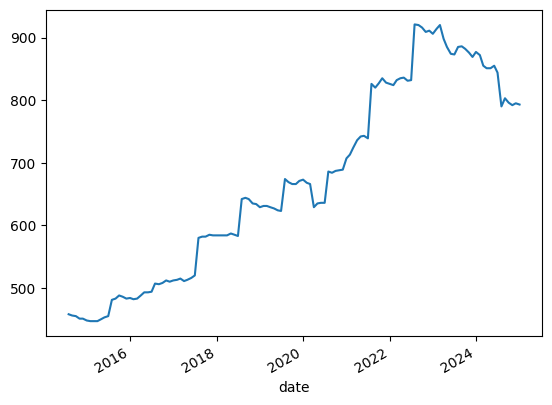

In [36]:
(global_universe_nan_mask == False).sum(axis=1).plot()

In [37]:
# `global_signal_0` in long format
global_signal_0_long = global_signal_0.stack().reset_index()
global_signal_0_long.columns = ['date', 'gvkey_iid', 'signal_0']

# `global_signal_1` in long format
global_signal_1_long = global_signal_1.stack().reset_index()
global_signal_1_long.columns = ['date', 'gvkey_iid', 'signal_1']

# `global_signal_2` in long format
global_signal_2_long = global_signal_2.stack().reset_index()
global_signal_2_long.columns = ['date', 'gvkey_iid', 'signal_2']

# `global_esg` in long format
#global_esg_long = global_esg.stack().reset_index()
#global_esg_long.columns = ['date', 'gvkey_iid', 'esg']

# Merged long dataset
global_long_df = global_signal_0_long.copy()

# Add signal_1
global_long_df = pd.merge(
    global_long_df, 
    global_signal_1_long, 
    on=['date', 'gvkey_iid'], 
    how='left'
)

# Add signal_2
global_long_df = pd.merge(
    global_long_df, 
    global_signal_2_long, 
    on=['date', 'gvkey_iid'], 
    how='left'
)

# Add ESG
# global_long_df = pd.merge(
#     global_long_df, 
#     global_esg_long, 
#     on=['date', 'gvkey_iid'], 
#     how='left'
# )

# Drop rows with missing values
global_long_df.dropna(subset=['signal_0', 'signal_1', 'signal_2'], inplace=True)#dropna(subset=['signal_0', 'signal_1', 'signal_2', 'esg'], inplace=True)

<Axes: title={'center': 'Count of NaNs in Global Returns'}, xlabel='date'>

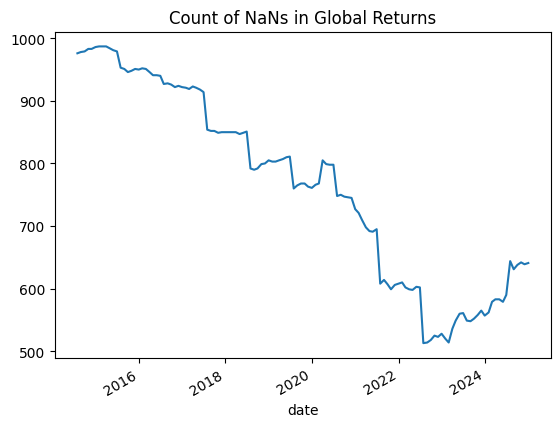

In [38]:
global_returns.isna().sum(axis=1).plot(title="Count of NaNs in Global Returns")

#### 3.1 Univariate sorting

In [39]:
# Memory pre-allocation for template
if take_extremes:
    univariate_sorting_template = pd.DataFrame({f"p_{i}" : np.nan for i in range(1, 4)}, index=global_signal_1.index)
else:
    univariate_sorting_template = pd.DataFrame({f"p_{i}" : np.nan for i in range(1, no_simple_quantiles+1)}, index=global_signal_1.index)

univariate_sorting_template.iloc[first_conditioning_set+1:, :] = 0.0

# Initialise simple_quantiles
signal_0_simple_quantiles = univariate_sorting_template.copy()
signal_1_simple_quantiles = univariate_sorting_template.copy()
signal_2_simple_quantiles = univariate_sorting_template.copy()
# emissions_simple_quantiles = univariate_sorting_template.copy()
# esg_simple_quantiles = univariate_sorting_template.copy()
# ros_beta_simple_quantiles = univariate_sorting_template.copy()
# combined_signal_max_min_simple_quantiles = univariate_sorting_template.copy()

# Initialise simple_quantiles constituents containers
signal_0_simple_quantiles_constituents = []
signal_1_simple_quantiles_constituents = []
signal_2_simple_quantiles_constituents = []
# emissions_simple_quantiles_constituents = []
# esg_simple_quantiles_constituents = []
# ros_beta_simple_quantiles_constituents = []
# combined_signal_max_min_simple_quantiles_constituents = []

# Loop over time periods
for i in range(first_conditioning_set, global_signal_1.shape[0]-1):
    
    # Current and following points in time
    current_signal_0 = global_signal_0.iloc[i, :]
    current_signal_1 = global_signal_1.iloc[i, :]
    current_signal_2 = global_signal_2.iloc[i, :]
    #current_emissions = global_emissions.iloc[i, :]
    #current_esg = global_esg.iloc[i, :]
    #current_ros_beta = global_ros_beta.iloc[i, :]
    current_combined_signal_max_min = global_combined_signal_max_min.iloc[i, :]
    next_ret = global_returns.iloc[i+1, :]

    # Deciles for current point in time
    current_signal_0_simple_quantiles = univariate_portfolio_sorting(current_signal_0, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    current_signal_1_simple_quantiles = univariate_portfolio_sorting(current_signal_1, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    current_signal_2_simple_quantiles = univariate_portfolio_sorting(current_signal_2, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    #current_emissions_simple_quantiles = univariate_portfolio_sorting(current_emissions, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    #current_esg_simple_quantiles = univariate_portfolio_sorting(current_esg, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    #current_ros_beta_simple_quantiles = univariate_portfolio_sorting(current_ros_beta, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)
    #current_combined_signal_max_min_simple_quantiles = univariate_portfolio_sorting(current_combined_signal_max_min, no_simple_quantiles, no_extremes_quantiles_1=no_simple_extremes_quantiles, take_extremes=take_extremes)

    # Update univariate sorting returns containers
    for col in current_signal_0_simple_quantiles.index:
        signal_0_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_0_simple_quantiles[col]].mean()
        signal_1_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_1_simple_quantiles[col]].mean()
        signal_2_simple_quantiles.iloc[i+1][col] += next_ret[current_signal_2_simple_quantiles[col]].mean()
        #emissions_simple_quantiles.iloc[i+1][col] += next_ret[current_emissions_simple_quantiles[col]].mean()
        #esg_simple_quantiles.iloc[i+1][col] += next_ret[current_esg_simple_quantiles[col]].mean()
        #ros_beta_simple_quantiles.iloc[i+1][col] += next_ret[current_ros_beta_simple_quantiles[col]].mean()
        #combined_signal_max_min_simple_quantiles.iloc[i+1][col] += next_ret[current_combined_signal_max_min_simple_quantiles[col]].mean()
    
    # Update univariate sorting constituents containers
    signal_0_simple_quantiles_constituents.append(current_signal_0_simple_quantiles)
    signal_1_simple_quantiles_constituents.append(current_signal_1_simple_quantiles)
    signal_2_simple_quantiles_constituents.append(current_signal_2_simple_quantiles)
    #emissions_simple_quantiles_constituents.append(current_emissions_simple_quantiles)
    #esg_simple_quantiles_constituents.append(current_esg_simple_quantiles)
    #ros_beta_simple_quantiles_constituents.append(current_ros_beta_simple_quantiles)
    #combined_signal_max_min_simple_quantiles_constituents.append(current_combined_signal_max_min_simple_quantiles)

What is in the portfolio 

<Axes: title={'center': 'Total Stocks - Split into 6 Portfolios'}>

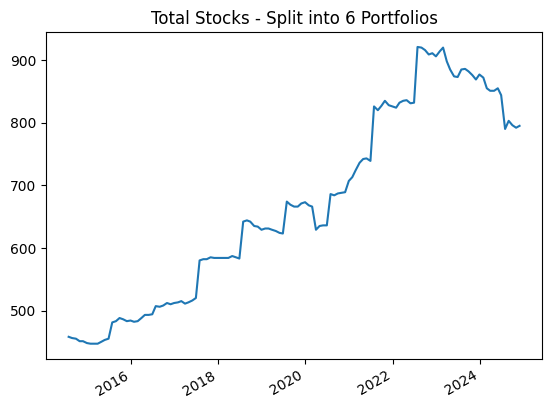

In [40]:
# 1. Calculate the sum of lengths for each month in the list
total_counts = pd.Series({
    month.name: month.apply(len).sum() 
    for month in signal_2_simple_quantiles_constituents
})

# 2. Plot the result
total_counts.plot(title=f"Total Stocks - Split into {no_simple_quantiles} Portfolios")

Add MSCI

In [41]:
MSCI = pd.read_excel("./data/MSCI/MSCI_World.xlsx", index_col= "Date")
MSCI["return"] = MSCI["MSCI_price"].pct_change()
MSCI.index = pd.to_datetime(MSCI.index)


#Intesrect the same dates:>

# Intersect on year-month (month-end day can differ from signal_0_simple_quantiles)
ym_msci = MSCI.index.to_period("M")
ym_sig = signal_0_simple_quantiles.index.to_period("M")
common_ym = ym_msci.unique().intersection(ym_sig.unique())

MSCI = MSCI[ym_msci.isin(common_ym)].sort_index()
# One row per month when MSCI is higher-frequency (last observation in each month)
MSCI = MSCI.groupby(MSCI.index.to_period("M"), sort=True).last()
MSCI.index = signal_0_simple_quantiles.index

Excess returns with risk free rate

In [42]:
# Transform in excess returns
signal_0_simple_quantiles = signal_0_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_1_simple_quantiles = signal_1_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_2_simple_quantiles = signal_2_simple_quantiles.sub(fama_french['rf'].values, axis=0)
MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)

In [43]:
def set_first_row_to_zero(df: pd.DataFrame, inplace: bool = False) -> pd.DataFrame:
    out = df if inplace else df.copy()
    out.iloc[0, :] = 0
    return out

In [44]:
global_returns = set_first_row_to_zero(global_returns)
signal_0_simple_quantiles = set_first_row_to_zero(signal_0_simple_quantiles)
signal_1_simple_quantiles = set_first_row_to_zero(signal_1_simple_quantiles)
signal_2_simple_quantiles = set_first_row_to_zero(signal_2_simple_quantiles)
MSCI_excess_returns.iloc[0] = 0

Plot Cumulative Returns

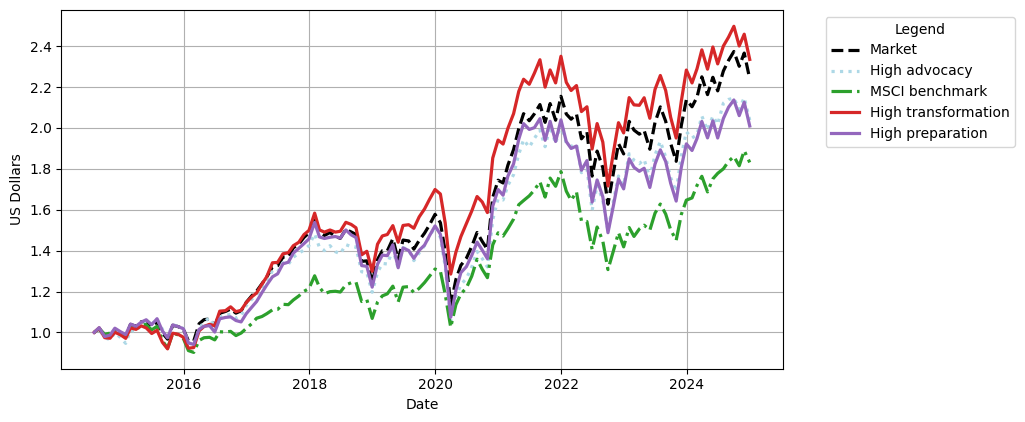

In [45]:
from matplotlib.cm import get_cmap

# Plotting data
global_gross_portfolio_returns = pd.DataFrame()
global_gross_portfolio_returns.index                   = global_returns.index
global_gross_portfolio_returns['Market']               = 1 + global_returns.mean(axis=1).sub(fama_french['rf'].values, axis=0)
global_gross_portfolio_returns['High advocacy']        = 1+signal_0_simple_quantiles[f'p_{no_simple_quantiles}']
#global_gross_portfolio_returns['Low advocacy']        = 1+signal_0_simple_quantiles[f'p_1']
global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

global_gross_portfolio_returns['High transformation']  = 1+signal_2_simple_quantiles[f'p_{no_simple_quantiles}']
#global_gross_portfolio_returns['High combined signal'] = 1+combined_signal_max_min_simple_quantiles[f'p_3']
global_gross_portfolio_returns['High preparation']     = 1+signal_1_simple_quantiles[f'p_{no_simple_quantiles}']
# Compute the cumulative product starting from 1
cumulative_products = global_gross_portfolio_returns.cumprod()



# Plotting
fig, ax = plt.subplots()
#cmap = get_cmap('viridis')
#colors = cmap(np.linspace(0, 1, len(global_gross_portfolio_returns.columns)))
colors = ['black', '#ADD8E6', '#2ca02c', '#d62728', '#9467bd']


line_styles = ['--', ':', '-.', '-', '-']#, (0, (3, 5, 1, 5))]
#line_styles = '-'
for i, col in enumerate(cumulative_products.columns):
    ax.plot(cumulative_products.index, cumulative_products[col], label=col, color=colors[i],linewidth=2.3, linestyle=line_styles[i])

ax.set_xlabel('Date')
ax.set_ylabel('US Dollars')
ax.grid(True)

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
plt.savefig(f'./img/cumulative_returns_high_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

### 5. Fama-french regressions

In [46]:
# Load relevant dependencies
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [47]:
def ff3_regressions(excess_returns, fama_french):

    stat_index = [
        'alpha',
        'beta_mkt',
        'beta_smb',
        'beta_hml',
        'p-value(alpha)',
        'p-value(beta_mkt)',
        'p-value(beta_smb)',
        'p-value(beta_hml)',
        'Adj. R^2',
    ]

    ff3_output = pd.DataFrame(np.nan, index=stat_index, columns=excess_returns.columns)

    # Gather FF3 factors
    independent_data = fama_french[['mktrf', 'smb', 'hml']]

    for col in excess_returns.columns:

        # Gather dependent data
        dependent_data = pd.Series(excess_returns[col].values, name='excrt')

        # Merge variables
        ols_data = 100 * pd.concat(
            [
                dependent_data,
                independent_data,
            ],
            axis=1,
        )

        # Skip missings
        ols_data = ols_data[ols_data.notna().all(axis=1)].reset_index(drop=True)

        if ols_data.empty:
            continue

        # Model
        mod = smf.ols(formula='excrt ~ mktrf + smb + hml', data=ols_data)

        # Estimate and show output
        fitted_model = mod.fit(cov_type='HC1')

        coef = fitted_model.params
        pval = fitted_model.pvalues

        ff3_output.loc['alpha', col] = coef.get('Intercept', np.nan)
        ff3_output.loc['beta_mkt', col] = coef.get('mktrf', np.nan)
        ff3_output.loc['beta_smb', col] = coef.get('smb', np.nan)
        ff3_output.loc['beta_hml', col] = coef.get('hml', np.nan)

        ff3_output.loc['p-value(alpha)', col] = pval.get('Intercept', np.nan)
        ff3_output.loc['p-value(beta_mkt)', col] = pval.get('mktrf', np.nan)
        ff3_output.loc['p-value(beta_smb)', col] = pval.get('smb', np.nan)
        ff3_output.loc['p-value(beta_hml)', col] = pval.get('hml', np.nan)
        ff3_output.loc['Adj. R^2', col] = fitted_model.rsquared_adj

    # Return regression output
    return ff3_output

In [48]:
# Table on FF3
ff3_parts = [
    low_high(ff3_regressions(signal_0_simple_quantiles, fama_french.reset_index(drop=True)), 'Advocacy'),
    low_high(ff3_regressions(signal_1_simple_quantiles, fama_french.reset_index(drop=True)), 'Prep'),
    low_high(ff3_regressions(signal_2_simple_quantiles, fama_french.reset_index(drop=True)), 'Transf'),
]

# if esg_choice != 'none':
#     ff3_parts += [
#         low_high(ff3_regressions(esg_simple_quantiles, fama_french.reset_index(drop=True)), 'ESG'),
#         low_high(ff3_regressions(signal_2_minus_esg_simple_quantiles, fama_french.reset_index(drop=True)), 'Signal2MinusESG'),
#         low_high(ff3_regressions(esg_signal_2_quantiles, fama_french.reset_index(drop=True)), 'ESGxTransf'),
#     ]

# ff3_parts += [
#     low_high(ff3_regressions(combined_signal_max_min_simple_quantiles, fama_french.reset_index(drop=True)), 'Combined'),
# ]

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
ff3_parts_df.to_csv('./tables/ff3_' + res_suffix + '.csv')

# # Table on downside risk
# risk_parts = [
#     low_high(risk((1 + signal_0_simple_quantiles).cumprod()).T, 'Advocacy'),
#     low_high(risk((1 + signal_1_simple_quantiles).cumprod()).T, 'Prep'),
#     low_high(risk((1 + signal_2_simple_quantiles).cumprod()).T, 'Transf'),
# ]

# if esg_choice != 'none':
#     risk_parts += [
#         low_high(risk((1 + esg_simple_quantiles).cumprod()).T, 'ESG'),
#         low_high(risk((1 + signal_2_minus_esg_simple_quantiles).cumprod()).T, 'Signal2MinusESG'),
#         low_high(risk((1 + esg_signal_2_quantiles).cumprod()).T, 'ESGxTransf'),
#     ]

# market_risk = risk(pd.DataFrame(1 + mkt_returns).cumprod()).T
# market_risk.columns = ['Market']

# risk_parts += [
#     low_high(risk((1 + ros_beta_simple_quantiles).cumprod()).T, 'RosBeta'),
#     low_high(risk((1 + combined_signal_max_min_simple_quantiles).cumprod()).T, 'Combined'),
#     market_risk,
# ]

# risk_parts_df = pd.concat(risk_parts, axis=1).round(2)
# risk_parts_df.to_csv('./tables/risk_' + res_suffix + '.csv')

In [49]:
ff3_parts_df

,Low Advocacy,High Advocacy,Low Prep,High Prep,Low Transf,High Transf
alpha,0.10,0.05,0.05,0.02,0.05,0.14
beta_mkt,1.10,1.12,1.07,1.15,1.13,1.07
beta_smb,0.18,0.21,0.13,0.22,0.17,0.14
beta_hml,0.19,0.27,0.20,0.25,0.26,0.17
p-value(alpha),0.31,0.62,0.61,0.85,0.58,0.18
p-value(beta_mkt),0.00,0.00,0.00,0.00,0.00,0.00
p-value(beta_smb),0.00,0.00,0.04,0.00,0.01,0.04
p-value(beta_hml),0.00,0.00,0.00,0.00,0.00,0.00
Adj. R^2,0.95,0.95,0.95,0.95,0.96,0.94


# Rolling Alpha

In [50]:
window_size = 40

# Initialize a list to collect results
all_results_list = []

# Always include the 3 core signals
signal_sets = [
    (0, signal_0_simple_quantiles.copy()),
    (1, signal_1_simple_quantiles.copy()),
    (2, signal_2_simple_quantiles.copy()),
]

# Only include ESG-related signals when ESG is enabled
# if esg_choice != 'none':
#     signal_sets += [
#         (3, esg_simple_quantiles.copy()),
#         (4, signal_2_minus_esg_simple_quantiles.copy()),
#     ]

for signal_id, signal_value in signal_sets:
    for i in range(len(signal_value) - window_size + 1):
        window_end_idx = i + window_size

        current_signal_value_window = signal_value.iloc[i:window_end_idx, :]
        current_ff_factors_window = fama_french.iloc[i:window_end_idx, :]

        regression_results_series = ff3_regressions(
            current_signal_value_window,
            current_ff_factors_window.reset_index(drop=True),
        ).iloc[0, :]

        # Get the date for the current window
        current_date = current_signal_value_window.index[-1]

        # Create a dictionary for the current row, including signal_id and date
        row_data = regression_results_series.to_dict()
        row_data['date'] = current_date
        row_data['signal_id'] = signal_id

        all_results_list.append(row_data)

# Convert the list of dictionaries to a DataFrame
all_window_results = pd.DataFrame(all_results_list)

# Set 'date' and 'signal_id' as index, and unstack 'signal_id' to get the desired wide format
all_window_results = all_window_results.set_index(['date', 'signal_id'])
all_window_results = all_window_results.unstack(level='signal_id')

# Optionally, sort columns for better presentation
all_window_results.sort_index(axis=1, level=1, inplace=True)

print(all_window_results.head())

                 p_1       p_2       p_3       p_4       p_5       p_6  \
signal_id          0         0         0         0         0         0   
date                                                                     
2017-10-31  0.396570  0.321302  0.295275  0.349466  0.377547  0.250938   
2017-11-30  0.325674  0.271375  0.232064  0.298570  0.339785  0.163562   
2017-12-29  0.340770  0.282173  0.224291  0.296519  0.344823  0.175953   
2018-01-31  0.417101  0.308689  0.283036  0.311486  0.376253  0.183138   
2018-02-28  0.387196  0.259267  0.285763  0.242901  0.394455  0.199191   

                 p_1       p_2       p_3       p_4       p_5       p_6  \
signal_id          1         1         1         1         1         1   
date                                                                     
2017-10-31  0.342462  0.366752  0.246403  0.307407  0.441754  0.270238   
2017-11-30  0.270501  0.290247  0.205968  0.267665  0.390425  0.189984   
2017-12-29  0.264375  0.271473  0.228

In [51]:
high_advocacy_alpha = all_window_results[f'p_{no_simple_quantiles}', 0]
high_preparation_alpha = all_window_results[f'p_{no_simple_quantiles}', 1]
high_transformation_alpha = all_window_results[f'p_{no_simple_quantiles}', 2]

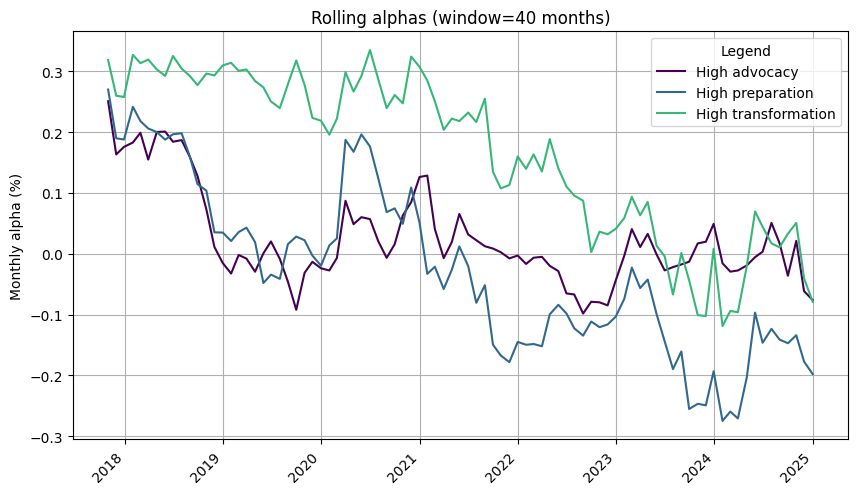

In [52]:
# --- Using Viridis Colormap ---
# Get the viridis colormap
cmap = plt.cm.get_cmap('viridis')

# Determine the number of lines to plot
num_lines = 4
colors = [cmap(i) for i in np.linspace(0, 1, num_lines)]
# np.linspace(0, 1, num_lines) generates evenly spaced numbers between 0 and 1
# cmap(value) gets the RGBA color from the colormap at that point

# Plotting
plt.figure(figsize=(10, 6)) # Adjust figure size for better readability

high_advocacy_alpha.plot(label='High advocacy', color=colors[0])
high_preparation_alpha.plot(label='High preparation', color=colors[1])
high_transformation_alpha.plot(label='High transformation', color=colors[2])
#high_esg_alpha.plot(label='High ESG', color=colors[3])

# Add a title
plt.title('Rolling alphas (window=40 months)')

# Add labels to the axes
plt.xlabel('')
plt.ylabel('Monthly alpha (%)')
plt.grid(True)
plt.xticks(rotation=45)  # Adjust x-axis labels for better readability

# Adjust the legend to be outside the plot
plt.legend(title='Legend')#, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig('./img/rolling_alphas_' + res_suffix + '.pdf')
plt.show()

# 6. Sector Split

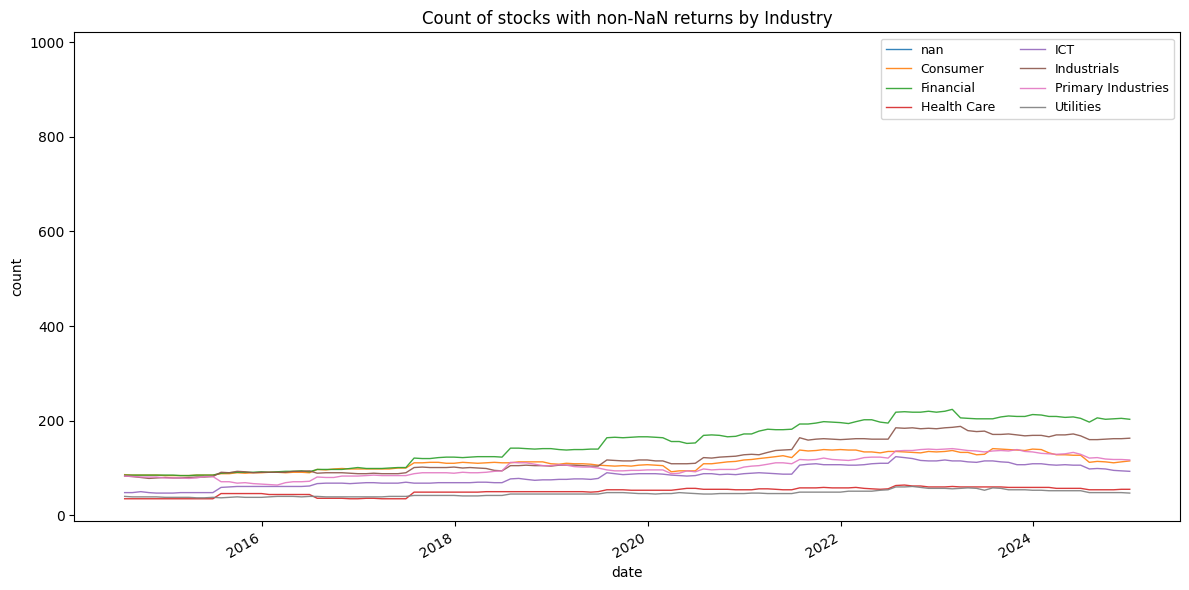

In [53]:
returns_long = (
    global_returns
      .stack(dropna=True)
      .rename("tr")
      .reset_index()
)
industry_map = (
    global_universe[["date", "gvkey_iid", "Industry"]]
      .drop_duplicates()
)
ret_with_ind = returns_long.merge(industry_map, on=["date", "gvkey_iid"], how="left")
counts_by_industry = (
    ret_with_ind
      .groupby(["date", "Industry"], dropna=False)["gvkey_iid"]
      .nunique()
      .rename("n_stocks_non_nan_return")
      .reset_index()
)
counts_wide = counts_by_industry.pivot(
    index="date", columns="Industry", values="n_stocks_non_nan_return"
)
ax = counts_wide.plot(figsize=(12, 6), linewidth=1, alpha=0.9)
ax.set_title("Count of stocks with non-NaN returns by Industry")
ax.set_xlabel("date")
ax.set_ylabel("count")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

In [54]:
counts_wide.describe().round(1)

Industry,NaN,Consumer,Financial,Health Care,ICT,Industrials,Primary Industries,Utilities
count,1.0,126.0,126.0,126.0,126.0,126.0,126.0,126.0
mean,974.0,111.7,151.9,50.3,83.6,124.1,102.4,45.9
std,NaN,17.6,47.1,8.6,21.3,35.3,21.8,6.2
min,974.0,84.0,84.0,35.0,47.0,78.0,64.0,37.0
25%,974.0,98.0,99.2,46.0,68.0,92.2,84.0,40.0
50%,974.0,111.0,156.0,53.0,84.5,109.5,97.0,45.5
75%,974.0,128.0,198.0,57.0,106.0,161.0,118.8,49.0
max,974.0,141.0,224.0,64.0,124.0,188.0,141.0,61.0


In [55]:
lc["Industry"].value_counts()

Industry
Consumer              11021
Industrials           10887
Financial              9256
Primary Industries     8622
ICT                    6968
Health Care            3672
Utilities              2185
Name: count, dtype: int64

In [56]:
even_split_no = 15

DEFAULT_INDUSTRY_COUNTS = {
    "Consumer": even_split_no,
    "Financial": even_split_no,
    "Financials": even_split_no,
    "Health Care": even_split_no,
    "ICT": even_split_no,
    "Industrials": even_split_no,
    "Primary Industries": even_split_no,
    "Utilities": even_split_no,
}

def top_x_by_industry(
    signal_row: pd.Series,
    industry_row: pd.Series,
    n_by_industry: dict | None = None,
    *,
    keep_industries: list[str] | None = None,
    ascending: bool = False,
) -> pd.Series:
    """
    Select top X tickers per industry for a single date.

    Parameters
    ----------
    signal_row : pd.Series
        Index = gvkey_iid, values = signal at one date (e.g., global_signal_2.iloc[i, :]).
    industry_row : pd.Series
        Index = gvkey_iid, values = Industry for the same date (aligned to signal_row.index).
    n_by_industry : dict
        Mapping Industry -> number of stocks to select. Defaults to DEFAULT_INDUSTRY_COUNTS.
    keep_industries : list[str]
        If provided, only these industries are processed (others ignored).
    ascending : bool
        False = pick largest signal (top). True = pick smallest (bottom).

    Returns
    -------
    pd.Series
        Index = industries, values = pd.Index of selected gvkey_iid for that industry.
        (Same “shape” idea as your quantile output: a container of constituents.)
    """
    if n_by_industry is None:
        n_by_industry = DEFAULT_INDUSTRY_COUNTS

    # Align & drop rows missing either signal or industry
    df = pd.DataFrame({"signal": signal_row, "Industry": industry_row}).dropna(subset=["signal", "Industry"])

    if keep_industries is not None:
        df = df[df["Industry"].isin(keep_industries)]

    out = pd.Series(dtype=object)

    # Process each industry separately
    for ind, g in df.groupby("Industry"):
        n = int(n_by_industry.get(ind, 0))
        if n <= 0:
            out.loc[ind] = pd.Index([], dtype=object)
            continue

        chosen = g.sort_values("signal", ascending=ascending).head(n).index
        out.loc[ind] = pd.Index(chosen)

    return out

Build an industry pivot aligned to global_returns / global_signal_*

In [57]:
global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

Store constituents over time + compute “next-month return” by Industry

In [58]:

industries = list[str](DEFAULT_INDUSTRY_COUNTS.keys())
industry_returns = pd.DataFrame(index=global_returns.index, columns=industries, dtype=float)
industry_returns.iloc[first_conditioning_set+1:, :] = 0.0

# Store constituents each period (this is your “variable that stores stocks selected each point in time”)
industry_constituents_over_time = []

for i in range(first_conditioning_set, global_returns.shape[0] - 1):
    date = global_returns.index[i]
    current_signal = global_signal_2.iloc[i, :]     # or signal_0/signal_1/combined
    current_industry = global_industry.iloc[i, :]
    next_ret = global_returns.iloc[i+1, :]

    selected = top_x_by_industry(
        signal_row=current_signal,
        industry_row=current_industry,
        n_by_industry=DEFAULT_INDUSTRY_COUNTS,  # can pass a custom dict here
        ascending=False,
    )

    # Save constituents for this date
    industry_constituents_over_time.append(selected)

    # Update industry return series (mean next-month return of selected stocks in each industry)
    for ind in selected.index:
        tickers = selected[ind]
        industry_returns.iloc[i+1, industry_returns.columns.get_loc(ind)] += next_ret[tickers].mean()
    
    selected.name = date   

# Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!

In [59]:
sector_portfolio_returns = industry_returns.mean(axis=1)

rfrate

In [60]:
sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)

#replace nan with 0 to ensure first elemtent matches
sector_portfolio_returns.iloc[0] = 0



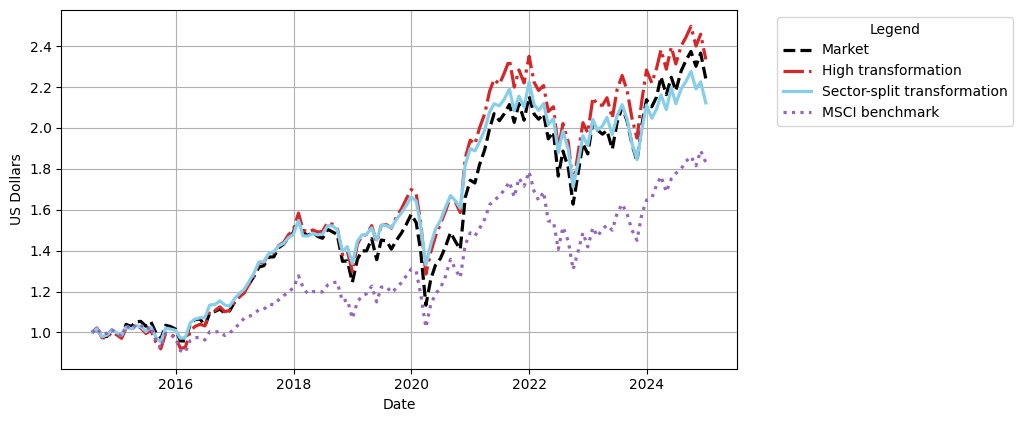

In [67]:
from matplotlib.cm import get_cmap

# Plotting data
global_gross_portfolio_returns = pd.DataFrame()
global_gross_portfolio_returns.index                   = global_returns.index
global_gross_portfolio_returns['Market']               = 1+global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)
global_gross_portfolio_returns['High transformation']  = 1+signal_2_simple_quantiles[f'p_{no_simple_quantiles}']
global_gross_portfolio_returns["Sector-split transformation"] =  1 + sector_portfolio_returns
global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

# Compute the cumulative product starting from 1
cumulative_products = global_gross_portfolio_returns.cumprod()



# Plotting
fig, ax = plt.subplots()
#cmap = get_cmap('viridis')
#colors = cmap(np.linspace(0, 1, len(global_gross_portfolio_returns.columns)))
colors = ['black','#d62728','#87CEEB','#9467bd', '#ADD8E6'  ]



#line_styles = ['-', '--', '-.', ':', (0, (3, 5, 1, 5))]
line_styles = ['--', '-.', '-', ':']#, (0, (3, 5, 1, 5))]
#line_styles = '-'
for i, col in enumerate(cumulative_products.columns):
    ax.plot(cumulative_products.index, cumulative_products[col], label=col, color=colors[i],linewidth=2.3, linestyle=line_styles[i])

ax.set_xlabel('Date')
ax.set_ylabel('US Dollars')
ax.grid(True)

# Adjust the legend to be outside the plot
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout(rect=[0, 0, 1.6, 0.9])  # Adjust the 'right' parameter to make room for the legend
plt.savefig(f'./img/cumulative_returns_high_' + res_suffix + '.pdf', bbox_inches='tight')  # bbox_inches='tight' helps to ensure all plot elements are included
plt.show()

# 8. More Performance Metrics

Plan:

1 - Cum returns table
2 - Sector and Region Split

Cum returns net of riskfree rate

In [68]:

portfolio_returns = global_gross_portfolio_returns - 1
portfolio_returns

,Market,High transformation,Sector-split transformation,MSCI benchmark
date,,,,
2014-07-31,0.000000,0.000000,0.000000,0.000000
2014-08-29,0.018196,0.021668,0.017621,0.020028
2014-09-30,-0.039106,-0.046353,-0.037866,-0.028753
2014-10-31,0.002137,-0.002906,0.007313,0.005702
2014-11-28,0.031494,0.029925,0.024199,0.018386
...,...,...,...,...
2024-08-30,0.022820,0.018105,0.017013,0.020306
2024-09-30,0.018674,0.021718,0.021722,0.012877
2024-10-31,-0.030483,-0.038569,-0.037621,-0.024285


In [69]:
from functions.Strategy_Perfomance import StrategyPerformance

sp = StrategyPerformance(portfolio_returns)
cumulative_table = sp.cumulative_performance_table(csv_path="./output/strategy_cumulative_performance.csv")
display(cumulative_table)


,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,-5.33%,-5.64%,4.78%,4.78%,3.96%,41.99%,125.06%,124.00%
High transformation,-5.02%,-6.49%,2.28%,2.28%,-0.66%,37.44%,136.31%,133.51%
Sector-split transformation,-4.63%,-6.75%,0.46%,0.46%,-4.55%,27.69%,112.49%,112.25%
MSCI benchmark,-3.06%,-1.56%,11.21%,11.21%,2.52%,39.80%,83.63%,83.13%


In [70]:
cumulative_products

,Market,High transformation,Sector-split transformation,MSCI benchmark
date,,,,
2014-07-31,1.000000,1.000000,1.000000,1.000000
2014-08-29,1.018196,1.021668,1.017621,1.020028
2014-09-30,0.978379,0.974311,0.979088,0.990699
2014-10-31,0.980469,0.971479,0.986248,0.996348
2014-11-28,1.011348,1.000551,1.010115,1.014667
...,...,...,...,...
2024-08-30,2.330482,2.444030,2.227737,1.836679
2024-09-30,2.374001,2.497109,2.276127,1.860329
2024-10-31,2.301634,2.400798,2.190496,1.815151
